In [24]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [25]:
def f(x):
    return 3*x**2 - 4*x + 5

In [26]:
f(3.0)

20.0

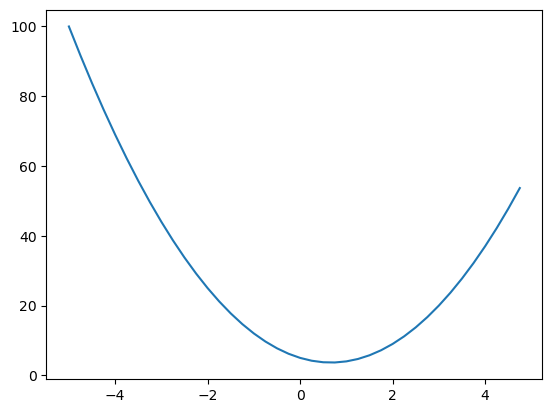

In [27]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [28]:
h = 0.00000000000001
x = 2/3
(f(x + h) - f(x)) / h # rise over run

0.0

In [29]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [30]:
h = 0.00001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 4.0
d2 4.00001
slope 0.9999999999621422


In [31]:
class Value:
    
    def __init__(self, data, _children=(), _op='', label=''): 
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            # accumulate gradients, contributions which flow back will be added on top of each other
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
    
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self, ), f'**{other}')
        
        def _backward():
            self.grad += other * self.data ** (other - 1) * out.grad # local gradient chained (mutliplied by "global" gradient)
        out._backward = _backward
        
        return(out)
        
        
    def __rmul__(self, other):
        return self * other
    
    def __radd__(self, other):
        return self + other
    
    def __rsub__(self, other):
        return self + (-other)
    
    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1)/(math.exp(2 * x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
            
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out
        
    def backward(self):
    
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [32]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

In [33]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

dL/dc # the derivative of L with respect to c

WANT
dL/dc

KNOW
dL/dd -2.0
dd/dc 1

dL/dc = (dL/dd) * (dd/dc


KNOW 
dL/de = -2.0

e = a * b
de / da = -3.0

dL/da = (dL / de) * (de / da)

In [34]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label = 'x2')
# weights w1, w1
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label = 'w2')
# bias
b = Value(6.8813735870195432, label = 'b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

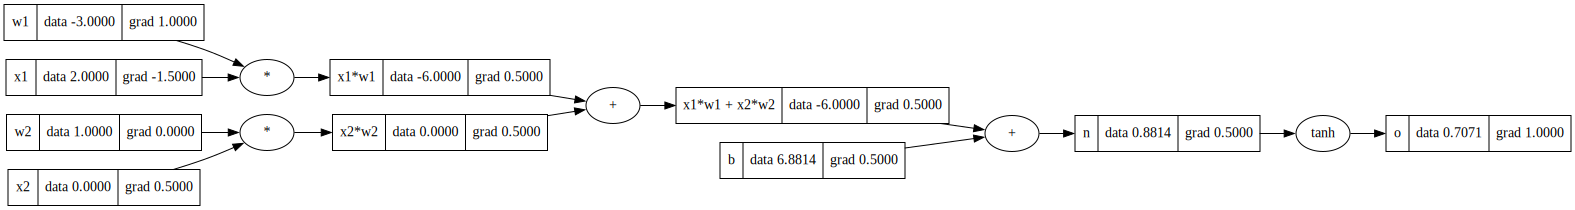

In [35]:
draw_dot(o)

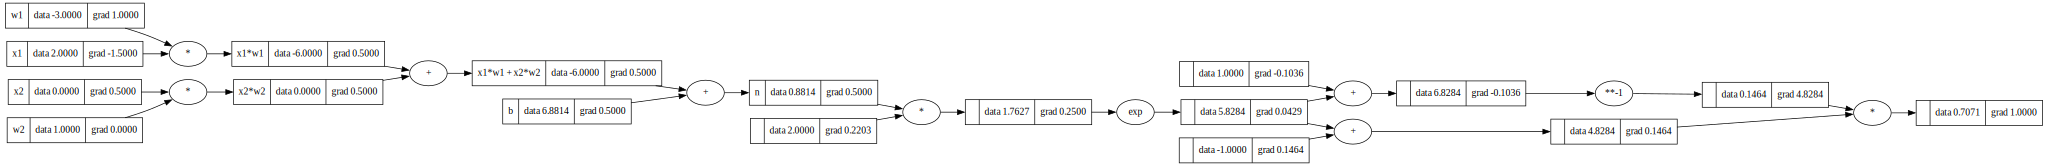

In [36]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label = 'x2')
# weights w1, w1
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label = 'w2')
# bias
b = Value(6.8813735870195432, label = 'b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2*n).exp()
o = (e-1)/(e+1)
o.backward()
draw_dot(o)

In [37]:
import torch

In [38]:
x1 = torch.Tensor([2.0]).double()       ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()       ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()      ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()       ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [39]:
random.uniform(-1,1)

-0.9423069028193447

In [40]:
[3] + [3, 4, 5]

[3, 3, 4, 5]

In [41]:
l = [1, 2, 3]
o = [2, 3]
l.append(o)
print(l)

[1, 2, 3, [2, 3]]


In [356]:
class Neuron:
    
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        
    def __call__(self, x):
        # w * x + b
        act = sum((wi * xi for wi,xi in zip(self.w, x)), self.b) 
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

In [357]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])

n(x) # call

Value(data=0.3462480757920508)

In [358]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, 1.0, -1.0]
ypred = [n(x) for x in xs]
print(ypred)

[Value(data=0.3462480757920508), Value(data=0.8606404234097027), Value(data=0.1078313495149441), Value(data=0.650695498626572)]


In [371]:
for k in range(10):
    
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
    
    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    
    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad
        
    print(k, loss.data)

0 0.01021030707807143
1 0.010058967665228034
2 0.009911832359249804
3 0.009768732346390606
4 0.009629507606579617
5 0.009494006353700585
6 0.009362084517776623
7 0.00923360526546706
8 0.009108438555627856
9 0.008986460726996628


In [372]:
ypred 

[Value(data=0.9430696709773515),
 Value(data=-0.9818265083565875),
 Value(data=0.963647535334783),
 Value(data=-0.9360185895855634)]

In [344]:
ypred = [n(x) for x in xs]
loss = sum([(yp - y)**2 for yp, y in zip(ypred, ys)])
loss

Value(data=0.0012922465460687657)

In [345]:
loss.backward()

In [346]:
for p in n.parameters():
    p.data += -0.001 * p.grad

In [347]:
ypred

[Value(data=0.9745727143249486),
 Value(data=-0.999999999997617),
 Value(data=0.9745893784163375),
 Value(data=-0.999999999997617)]

In [348]:
n.parameters()

[Value(data=-0.014725816099175454),
 Value(data=3.649816637122356),
 Value(data=4.796086205170723),
 Value(data=0.2849338767119631),
 Value(data=2.0053639471054043),
 Value(data=-4.063481971828225),
 Value(data=-5.24725494216946),
 Value(data=-0.8863524783442135),
 Value(data=1.5785073406565078),
 Value(data=4.763809778020215),
 Value(data=2.6522086666561187),
 Value(data=4.098424525404861),
 Value(data=-1.4733199581144116),
 Value(data=-2.9462251385578364),
 Value(data=-1.798624554560971),
 Value(data=-1.9911792290650792),
 Value(data=-0.8533078787681304),
 Value(data=2.019067780738494),
 Value(data=1.2070424004763876),
 Value(data=-2.2103664608057416),
 Value(data=2.686208564997698),
 Value(data=0.0038818304634720873),
 Value(data=-0.5105491109027582),
 Value(data=2.1311773027403897),
 Value(data=-1.050999479802746),
 Value(data=3.125372837512773),
 Value(data=-0.6210612679653988),
 Value(data=0.48350532488270415),
 Value(data=0.6778410245974198),
 Value(data=-1.8383197915957614),
 V